<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 5 - Modelos de Ensambles - XGBoost y Backtesting Evolutivo</h3>
    <h3>Ejercicio 1B_Sincronico</h3>
        <p>Docentes: Rodrigo Del Rosso, Drago Braian, Sebastian Calcagno <p>
</div>

Este notebook toma como base el ejercicio original de consumo horario PJME y mantiene su condición central de backtesting:

```python
TimeSeriesSplit(n_splits=5, test_size=24*365)
```

Esto significa **5 simulaciones históricas**, cada una evaluando **un año completo**.

El contenido avanza de forma evolutiva:

1. Construcción correcta de una fila de predictores.
2. Holdout temporal final.
3. Backtesting anual con ventana expansiva.
4. Backtesting anual con ventana deslizante.
5. Uso y significado de `gap`.
6. Diferencia entre validación tabular y forecast recursivo.
7. Comparación con un baseline.

> **Idea central:** el horizonte de validación debe representar la pregunta que queremos responder. La condición anual se conserva para medir desempeño a través de ciclos estacionales completos. El ejemplo recursivo usa 48 horas porque representa una pregunta operativa diferente y permite mostrar la acumulación de predicciones sin realizar 8.760 iteraciones por fold.

## 0. Librerías y configuración

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.base import clone
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

## 1. Carga de datos

El notebook intenta cargar el dataset real desde GitHub. Si no hay conexión, genera una serie sintética horaria con patrones diarios, semanales y anuales. El origen utilizado queda impreso para no confundir resultados reales con simulados.

In [ ]:
from io import StringIO
import requests

URL = "https://raw.githubusercontent.com/braiandrago/AST/main/consumo_2.csv"
df_raw = pd.read_csv(URL)
df_raw.info()

respuesta = requests.get(URL, timeout=20)
respuesta.raise_for_status()
df_raw = pd.read_csv(StringIO(respuesta.text))
df_raw["Datetime"] = pd.to_datetime(df_raw["Datetime"])
df_raw = df_raw.set_index("Datetime").sort_index()
ORIGEN_DATOS = "PJME real desde GitHub"
print("Origen:", ORIGEN_DATOS)
print("Forma:", df_raw.shape)
display(df_raw.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB
Origen: PJME real desde GitHub
Forma: (145366, 1)


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


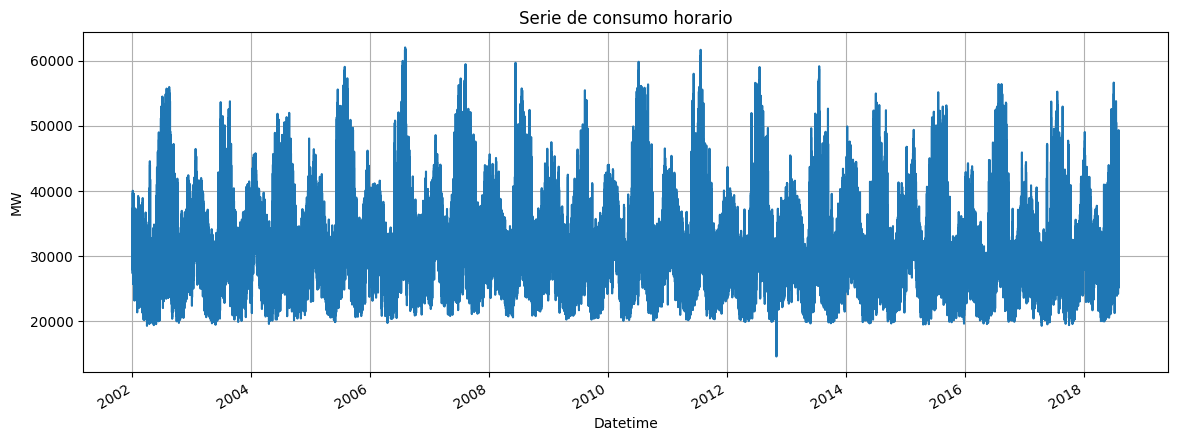

In [ ]:
df_raw["PJME_MW"].plot(title="Serie de consumo horario")
plt.ylabel("MW")
plt.show()

## 2. Construcción correcta del vector fila

El script original **construye correctamente** las variables calendario y los lags:

- `hour`, `dayofweek`, `month`, etc. se calculan desde la fecha de la propia fila.
- Los lags se obtienen desde observaciones anteriores de la variable objetivo.

Eso no desplaza indiscriminadamente todo el vector. Cada columna conserva su significado.

El riesgo aparece después si evaluamos un horizonte largo usando filas de validación ya construidas con valores reales intermedios que, en un forecast recursivo, todavía no conoceríamos.

In [ ]:
def crear_features_calendario(df):
    out = df.copy()
    out["hour"] = out.index.hour
    out["dayofweek"] = out.index.dayofweek
    out["month"] = out.index.month
    out["quarter"] = out.index.quarter
    out["dayofyear"] = out.index.dayofyear
    return out


def agregar_lags(df, lags=(1, 24, 168)):
    out = df.copy()
    for lag in lags:
        out[f"lag_{lag}"] = out["PJME_MW"].shift(lag)
    out["media_24"] = out["PJME_MW"].shift(1).rolling(24).mean()
    return out


df = crear_features_calendario(df_raw)
df = agregar_lags(df, lags=(1, 24, 168))
df = df.dropna().copy()

FEATURES = ["hour", "dayofweek", "month", "quarter", "dayofyear",
            "lag_1", "lag_24", "lag_168", "media_24"]
TARGET = "PJME_MW"

display(df[FEATURES + [TARGET]].head())

,hour,dayofweek,month,quarter,dayofyear,lag_1,lag_24,lag_168,media_24,PJME_MW
Datetime,,,,,,,,,,
2002-01-08 01:00:00,1,1,1,1,8,31187.0,26862.0,30393.0,33452.583333,29445.0
2002-01-08 02:00:00,2,1,1,1,8,29445.0,25976.0,29265.0,33560.208333,28670.0
2002-01-08 03:00:00,3,1,1,1,8,28670.0,25641.0,28357.0,33672.458333,28375.0
2002-01-08 04:00:00,4,1,1,1,8,28375.0,25666.0,27899.0,33786.375000,28542.0
2002-01-08 05:00:00,5,1,1,1,8,28542.0,26328.0,28057.0,33906.208333,29261.0


### Dibujo de alineación temporal

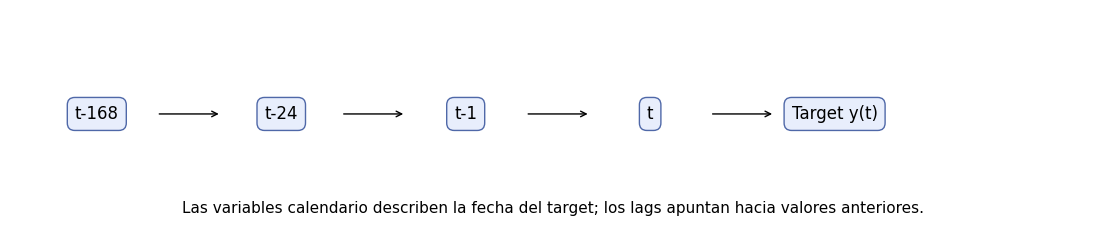

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")
xs = [0.08, 0.25, 0.42, 0.59, 0.76]
labels = ["t-168", "t-24", "t-1", "t", "Target y(t)"]
for x, lab in zip(xs, labels):
    ax.text(x, .55, lab, ha="center", va="center", fontsize=12,
            bbox=dict(boxstyle="round,pad=.45", fc="#e8eefc", ec="#4f68a8"))
for x1, x2 in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(x2-.055,.55), xytext=(x1+.055,.55), arrowprops=dict(arrowstyle="->"))
ax.text(.5,.12,"Las variables calendario describen la fecha del target; los lags apuntan hacia valores anteriores.",ha="center",fontsize=11)
plt.show()

## 3. Nivel 1 — Holdout temporal simple

Train / desarrollo: 2002-01-08 01:00:00 → 2017-08-02 23:00:00 136437
Test final reservado: 2017-08-03 00:00:00 → 2018-08-03 00:00:00 8761


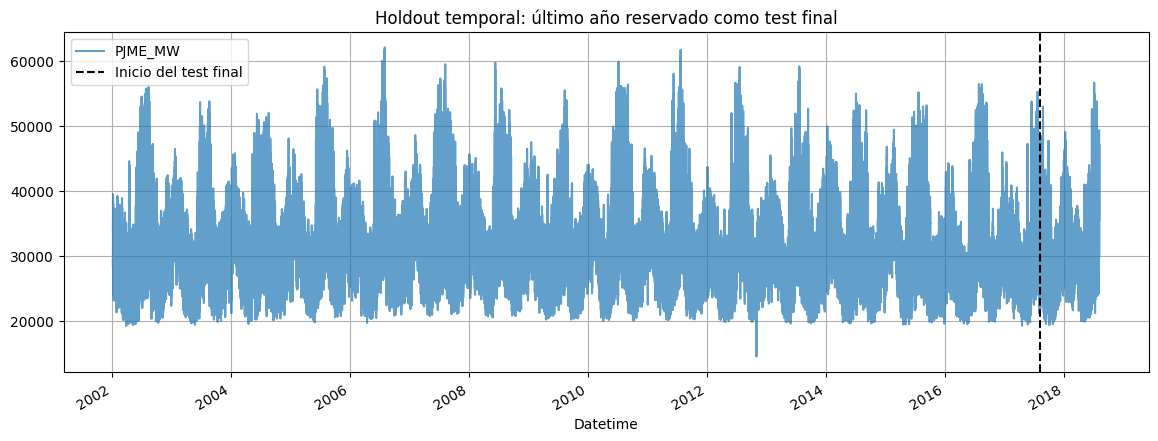

In [ ]:
# Reservamos el último año como test final.
# Este período NO participa en el backtesting ni en la elección del modelo.
corte = df.index.max() - pd.Timedelta(days=365)
train = df.loc[df.index < corte]
test_final = df.loc[df.index >= corte]

print("Train / desarrollo:", train.index.min(), "→", train.index.max(), len(train))
print("Test final reservado:", test_final.index.min(), "→", test_final.index.max(), len(test_final))

ax = df[TARGET].plot(alpha=.7, title="Holdout temporal: último año reservado como test final")
ax.axvline(corte, color="black", linestyle="--", label="Inicio del test final")
ax.legend()
plt.show()

El último año queda completamente reservado. Los cinco folds anuales se generan únicamente dentro del conjunto de desarrollo `train`. Así evitamos elegir configuraciones mirando el período final.

In [ ]:
from matplotlib.lines import Line2D

ROLE_COLORS = {
    "train": "#2563eb",
    "val": "#dc2626",
    "gap": "#f59e0b"
}


def resumen_split(splitter, X):
    filas = []
    for fold, (tr, va) in enumerate(splitter.split(X), start=1):
        gap_n = max(0, va[0] - tr[-1] - 1)
        gap_inicio = X.index[tr[-1] + 1] if gap_n > 0 else pd.NaT
        gap_fin = X.index[va[0] - 1] if gap_n > 0 else pd.NaT
        filas.append({
            "fold": fold,
            "train_inicio": X.index[tr[0]],
            "train_fin": X.index[tr[-1]],
            "n_train": len(tr),
            "gap_inicio": gap_inicio,
            "gap_fin": gap_fin,
            "n_gap": gap_n,
            "val_inicio": X.index[va[0]],
            "val_fin": X.index[va[-1]],
            "n_val": len(va)
        })
    return pd.DataFrame(filas)



def graficar_ventanas(splitter, X, titulo, mostrar_gap=True):
    resumen = resumen_split(splitter, X)
    fig, ax = plt.subplots(figsize=(14, max(3.8, 1.25 * len(resumen))))

    for _, row in resumen.iterrows():
        y = int(row["fold"])
        ax.plot([row["train_inicio"], row["train_fin"]], [y, y],
                color=ROLE_COLORS["train"], lw=10, solid_capstyle="butt")
        if mostrar_gap and row["n_gap"] > 0:
            ax.plot([row["gap_inicio"], row["gap_fin"]], [y, y],
                    color=ROLE_COLORS["gap"], lw=10, solid_capstyle="butt")
        ax.plot([row["val_inicio"], row["val_fin"]], [y, y],
                color=ROLE_COLORS["val"], lw=10, solid_capstyle="butt")

        ax.text(row["train_fin"], y + 0.18, f"train={int(row['n_train'])}",
                color=ROLE_COLORS["train"], ha="right", va="bottom", fontsize=9)
        ax.text(row["val_inicio"], y + 0.18, f"val={int(row['n_val'])}",
                color=ROLE_COLORS["val"], ha="left", va="bottom", fontsize=9)
        if mostrar_gap and row["n_gap"] > 0:
            mid_gap = row["gap_inicio"] + (row["gap_fin"] - row["gap_inicio"]) / 2
            ax.text(mid_gap, y - 0.24, f"gap={int(row['n_gap'])}",
                    color="#92400e", ha="center", va="top", fontsize=9)

    handles = [
        Line2D([0], [0], color=ROLE_COLORS["train"], lw=10, label="Train"),
        Line2D([0], [0], color=ROLE_COLORS["val"], lw=10, label="Validación")
    ]
    if mostrar_gap and resumen["n_gap"].gt(0).any():
        handles.insert(1, Line2D([0], [0], color=ROLE_COLORS["gap"], lw=10, label="Gap"))

    ax.set_title(titulo)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Fold")
    ax.set_yticks(range(1, len(resumen) + 1))
    ax.set_ylim(0.5, len(resumen) + 0.5)
    ax.legend(handles=handles, loc="upper left")
    plt.tight_layout()
    plt.show()
    return resumen


## 4. Nivel 2 — Backtesting anual con ventana expansiva

Se conserva la configuración original:

```python
TimeSeriesSplit(n_splits=5, test_size=24*365)
```

- `n_splits=5`: se realizan cinco simulaciones históricas.
- `test_size=24*365`: cada validación contiene 8.760 horas, aproximadamente un año completo.
- `gap=0`: la validación comienza inmediatamente después del train.
- Sin `max_train_size`: el entrenamiento es **expansivo**; comienza siempre en la misma fecha y agrega el año anterior en cada fold.

Evaluar un año completo permite incluir verano, invierno, días laborales, fines de semana y estacionalidad anual.

Configuración original conservada:
- 5 folds.
- 1 año de validación por fold: 8.760 horas.
- Ventana expansiva: el train crece exactamente un bloque anual en cada fold.



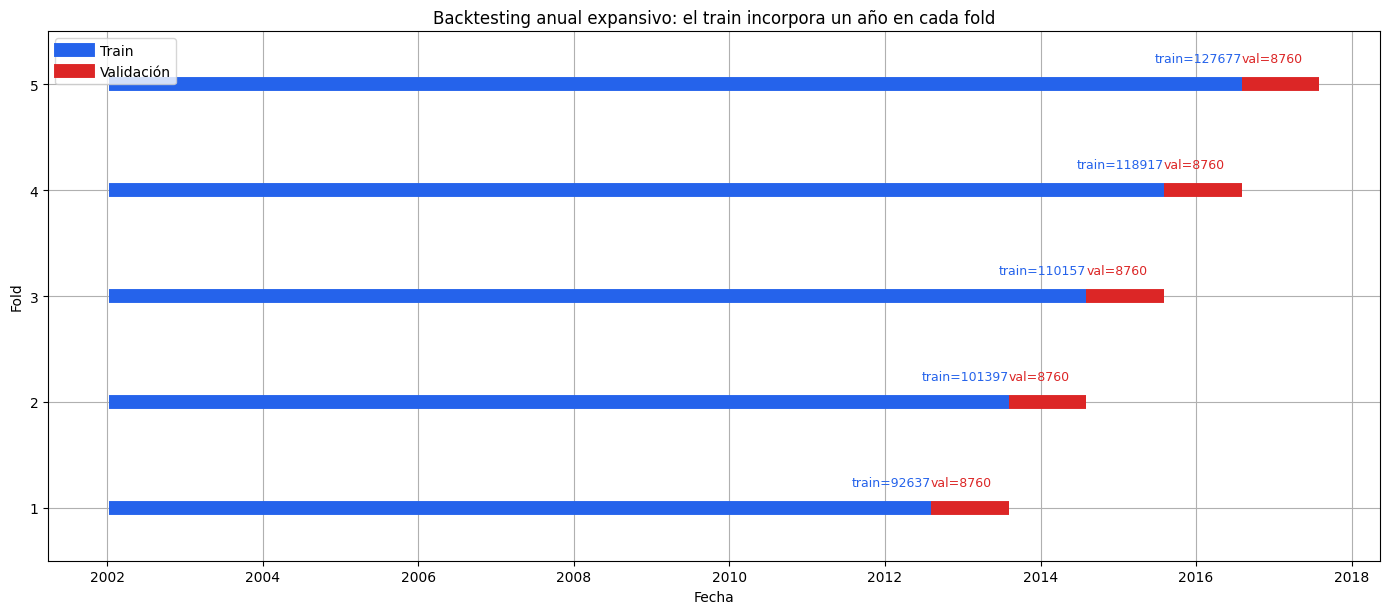

,fold,train_inicio,train_fin,n_train,gap_inicio,gap_fin,n_gap,val_inicio,val_fin,n_val
0,1,2002-01-08 01:00:00,2012-08-03 19:00:00,92637,NaT,NaT,0,2012-08-03 20:00:00,2013-08-03 21:00:00,8760
1,2,2002-01-08 01:00:00,2013-08-03 21:00:00,101397,NaT,NaT,0,2013-08-03 22:00:00,2014-08-03 23:00:00,8760
2,3,2002-01-08 01:00:00,2014-08-03 23:00:00,110157,NaT,NaT,0,2014-08-04 00:00:00,2015-08-03 23:00:00,8760
3,4,2002-01-08 01:00:00,2015-08-03 23:00:00,118917,NaT,NaT,0,2015-08-04 00:00:00,2016-08-02 23:00:00,8760
4,5,2002-01-08 01:00:00,2016-08-02 23:00:00,127677,NaT,NaT,0,2016-08-03 00:00:00,2017-08-02 23:00:00,8760


Crecimiento del train respecto del primer fold:


,fold,train_inicio,train_fin,n_train,val_inicio,val_fin,n_val,crecimiento_vs_fold_1,años_adicionales_aprox
0,1,2002-01-08 01:00:00,2012-08-03 19:00:00,92637,2012-08-03 20:00:00,2013-08-03 21:00:00,8760,0,0.0
1,2,2002-01-08 01:00:00,2013-08-03 21:00:00,101397,2013-08-03 22:00:00,2014-08-03 23:00:00,8760,8760,1.0
2,3,2002-01-08 01:00:00,2014-08-03 23:00:00,110157,2014-08-04 00:00:00,2015-08-03 23:00:00,8760,17520,2.0
3,4,2002-01-08 01:00:00,2015-08-03 23:00:00,118917,2015-08-04 00:00:00,2016-08-02 23:00:00,8760,26280,3.0
4,5,2002-01-08 01:00:00,2016-08-02 23:00:00,127677,2016-08-03 00:00:00,2017-08-02 23:00:00,8760,35040,4.0


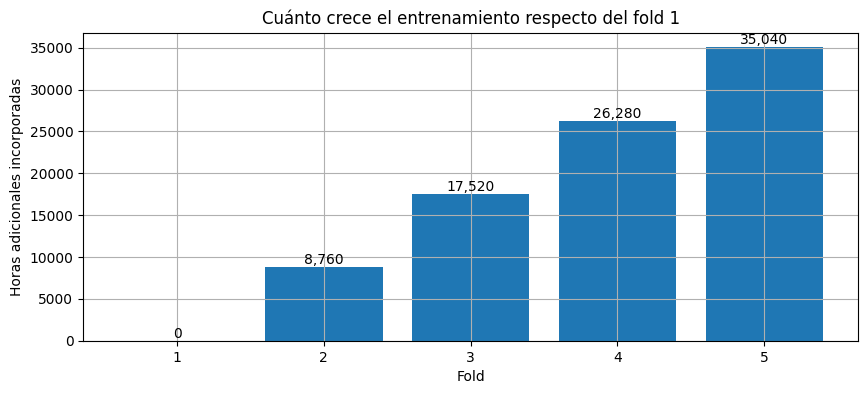

In [ ]:
X_dev = train[FEATURES]
y_dev = train[TARGET]

HORAS_ANIO = 24 * 365

split_exp = TimeSeriesSplit(
    n_splits=5,
    test_size=HORAS_ANIO,
    gap=0
)

print("Configuración original conservada:")
print("- 5 folds.")
print("- 1 año de validación por fold: 8.760 horas.")
print("- Ventana expansiva: el train crece exactamente un bloque anual en cada fold.")
print()

resumen_exp = graficar_ventanas(
    split_exp,
    X_dev,
    titulo="Backtesting anual expansivo: el train incorpora un año en cada fold"
)

display(resumen_exp)

# Tabla específica para hacer visible el crecimiento
crecimiento_exp = resumen_exp[["fold", "train_inicio", "train_fin", "n_train", "val_inicio", "val_fin", "n_val"]].copy()
crecimiento_exp["crecimiento_vs_fold_1"] = crecimiento_exp["n_train"] - crecimiento_exp["n_train"].iloc[0]
crecimiento_exp["años_adicionales_aprox"] = crecimiento_exp["crecimiento_vs_fold_1"] / HORAS_ANIO

print("Crecimiento del train respecto del primer fold:")
display(crecimiento_exp)

# Gráfico del crecimiento en cantidad de observaciones, más fácil de leer que la escala completa de fechas
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(crecimiento_exp["fold"].astype(str), crecimiento_exp["crecimiento_vs_fold_1"])
ax.set_title("Cuánto crece el entrenamiento respecto del fold 1")
ax.set_xlabel("Fold")
ax.set_ylabel("Horas adicionales incorporadas")
for _, row in crecimiento_exp.iterrows():
    ax.text(str(int(row["fold"])), row["crecimiento_vs_fold_1"],
            f'{int(row["crecimiento_vs_fold_1"]):,}', ha="center", va="bottom")
plt.show()

In [ ]:
modelo_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=20,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)


def backtesting_tabular(modelo_base, X, y, splitter):
    filas=[]
    preds=[]
    for fold,(tr,va) in enumerate(splitter.split(X),1):
        modelo=clone(modelo_base)
        X_tr,X_va=X.iloc[tr],X.iloc[va]
        y_tr,y_va=y.iloc[tr],y.iloc[va]
        modelo.fit(X_tr,y_tr)
        y_hat=modelo.predict(X_va)
        filas.append({
            "fold":fold,
            "inicio_train":y_tr.index.min(),"fin_train":y_tr.index.max(),
            "inicio_val":y_va.index.min(),"fin_val":y_va.index.max(),
            "n_train":len(y_tr),
            "MAE":mean_absolute_error(y_va,y_hat),
            "RMSE":mean_squared_error(y_va,y_hat)**0.5
        })
        preds.append(pd.DataFrame({"real":y_va.values,"pred":y_hat,"fold":fold},index=y_va.index))
    return pd.DataFrame(filas),pd.concat(preds)

res_exp,pred_exp=backtesting_tabular(modelo_base,X_dev,y_dev,split_exp)
print("Resultados por fold — validación anual expansiva:")
display(res_exp)
print("Resumen de métricas:")
display(res_exp[["MAE","RMSE"]].agg(["mean","std","min","max"]))


Resultados por fold — validación anual expansiva:


,fold,inicio_train,fin_train,inicio_val,fin_val,n_train,MAE,RMSE
0,1,2002-01-08 01:00:00,2012-08-03 19:00:00,2012-08-03 20:00:00,2013-08-03 21:00:00,92637,1397.571974,1851.575885
1,2,2002-01-08 01:00:00,2013-08-03 21:00:00,2013-08-03 22:00:00,2014-08-03 23:00:00,101397,1387.938473,1772.301528
2,3,2002-01-08 01:00:00,2014-08-03 23:00:00,2014-08-04 00:00:00,2015-08-03 23:00:00,110157,1393.151522,1757.061823
3,4,2002-01-08 01:00:00,2015-08-03 23:00:00,2015-08-04 00:00:00,2016-08-02 23:00:00,118917,1408.108719,1796.054362
4,5,2002-01-08 01:00:00,2016-08-02 23:00:00,2016-08-03 00:00:00,2017-08-02 23:00:00,127677,1458.529281,1883.945095


Resumen de métricas:


,MAE,RMSE
mean,1409.059994,1812.187738
std,28.632534,53.829840
min,1387.938473,1757.061823
max,1458.529281,1883.945095


## 5. Nivel 3 — Backtesting anual con ventana deslizante

Mantenemos exactamente los mismos **5 folds** y el mismo **año de validación**, pero limitamos el train a los últimos cinco años:

```python
TimeSeriesSplit(
    n_splits=5,
    test_size=24*365,
    max_train_size=24*365*5
)
```

Esto permite una comparación justa: cambia solamente la memoria histórica del modelo.

- Expansiva: usa todo el pasado disponible.
- Deslizante: usa únicamente los cinco años más recientes.

Elegimos cinco años para conservar varios ciclos anuales y, al mismo tiempo, descartar historia demasiado antigua.

Interpretación:
- La validación sigue siendo anual y tiene el mismo tamaño que en la expansiva.
- El train tiene como máximo cinco años.
- En cada fold el bloque azul se desplaza hacia adelante sin crecer indefinidamente.



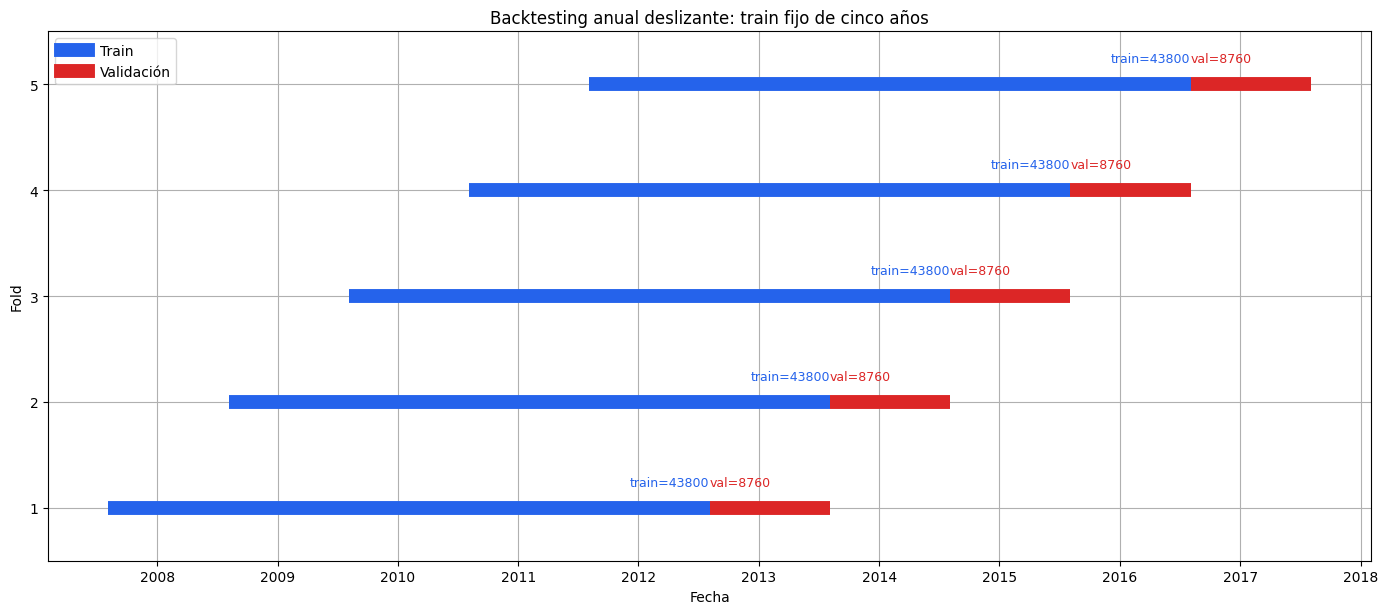

,fold,train_inicio,train_fin,n_train,gap_inicio,gap_fin,n_gap,val_inicio,val_fin,n_val
0,1,2007-08-05 09:00:00,2012-08-03 19:00:00,43800,NaT,NaT,0,2012-08-03 20:00:00,2013-08-03 21:00:00,8760
1,2,2008-08-04 11:00:00,2013-08-03 21:00:00,43800,NaT,NaT,0,2013-08-03 22:00:00,2014-08-03 23:00:00,8760
2,3,2009-08-04 13:00:00,2014-08-03 23:00:00,43800,NaT,NaT,0,2014-08-04 00:00:00,2015-08-03 23:00:00,8760
3,4,2010-08-04 15:00:00,2015-08-03 23:00:00,43800,NaT,NaT,0,2015-08-04 00:00:00,2016-08-02 23:00:00,8760
4,5,2011-08-04 18:00:00,2016-08-02 23:00:00,43800,NaT,NaT,0,2016-08-03 00:00:00,2017-08-02 23:00:00,8760


Resultados por fold — ventana deslizante anual:


,fold,inicio_train,fin_train,inicio_val,fin_val,n_train,MAE,RMSE
0,1,2007-08-05 09:00:00,2012-08-03 19:00:00,2012-08-03 20:00:00,2013-08-03 21:00:00,43800,1406.060152,1852.314421
1,2,2008-08-04 11:00:00,2013-08-03 21:00:00,2013-08-03 22:00:00,2014-08-03 23:00:00,43800,1389.163634,1776.028333
2,3,2009-08-04 13:00:00,2014-08-03 23:00:00,2014-08-04 00:00:00,2015-08-03 23:00:00,43800,1372.294863,1729.597577
3,4,2010-08-04 15:00:00,2015-08-03 23:00:00,2015-08-04 00:00:00,2016-08-02 23:00:00,43800,1383.615054,1766.957810
4,5,2011-08-04 18:00:00,2016-08-02 23:00:00,2016-08-03 00:00:00,2017-08-02 23:00:00,43800,1404.328952,1863.431541


Comparación de métricas medias usando el mismo horizonte anual:


,Expansiva_toda_la_historia,Deslizante_ultimos_5_anios
MAE,1409.059994,1391.092531
RMSE,1812.187738,1797.665937


In [ ]:
VENTANA_TRAIN_ANIOS = 5

split_roll = TimeSeriesSplit(
    n_splits=5,
    test_size=HORAS_ANIO,
    max_train_size=HORAS_ANIO * VENTANA_TRAIN_ANIOS,
    gap=0
)

print("Interpretación:")
print("- La validación sigue siendo anual y tiene el mismo tamaño que en la expansiva.")
print("- El train tiene como máximo cinco años.")
print("- En cada fold el bloque azul se desplaza hacia adelante sin crecer indefinidamente.")
print()

resumen_roll = graficar_ventanas(
    split_roll,
    X_dev,
    titulo="Backtesting anual deslizante: train fijo de cinco años"
)

display(resumen_roll)

res_roll,pred_roll=backtesting_tabular(modelo_base,X_dev,y_dev,split_roll)
comparacion=pd.DataFrame({
    "Expansiva_toda_la_historia":res_exp[["MAE","RMSE"]].mean(),
    "Deslizante_ultimos_5_anios":res_roll[["MAE","RMSE"]].mean()
})
print("Resultados por fold — ventana deslizante anual:")
display(res_roll)
print("Comparación de métricas medias usando el mismo horizonte anual:")
display(comparacion)

La comparación tiene sentido porque ambos esquemas validan exactamente los mismos cinco bloques anuales. La única diferencia es cuánta historia recibe el modelo. Si la ventana deslizante mejora, sugiere que los datos antiguos pueden haber perdido relevancia; si empeora, la historia larga todavía aporta información.

## 6. Nivel 4 — Gap dentro del backtesting anual

Se conserva la validación anual y se introduce un `gap` de 24 horas:

```python
TimeSeriesSplit(
    n_splits=5,
    test_size=24*365,
    max_train_size=24*365*5,
    gap=24
)
```

El gap excluye las últimas 24 horas del train antes de comenzar la validación.

### Qué beneficio puede tener

1. **Demora operativa:** al emitir el forecast, el último día todavía no está consolidado.
2. **Embargo o purga:** queremos separar temporalmente train y validación.
3. **Solapamiento:** ciertos targets o ventanas pueden compartir información en los bordes.

### Qué no hace

`TimeSeriesSplit` no pronostica automáticamente las 24 horas del gap. Solo las excluye del entrenamiento.

Además, si `X_val` fue preconstruido con los datos completos, el primer `lag_1` de la validación puede usar el último valor real del gap. Eso es válido solamente si ese gap ya era conocido como contexto al emitir el forecast. Si el gap representa datos realmente desconocidos, hay que atravesarlo recursivamente.

Interpretación:
- Azul = train de hasta cinco años.
- Naranja = 24 horas excluidas del train.
- Rojo = un año completo de validación.



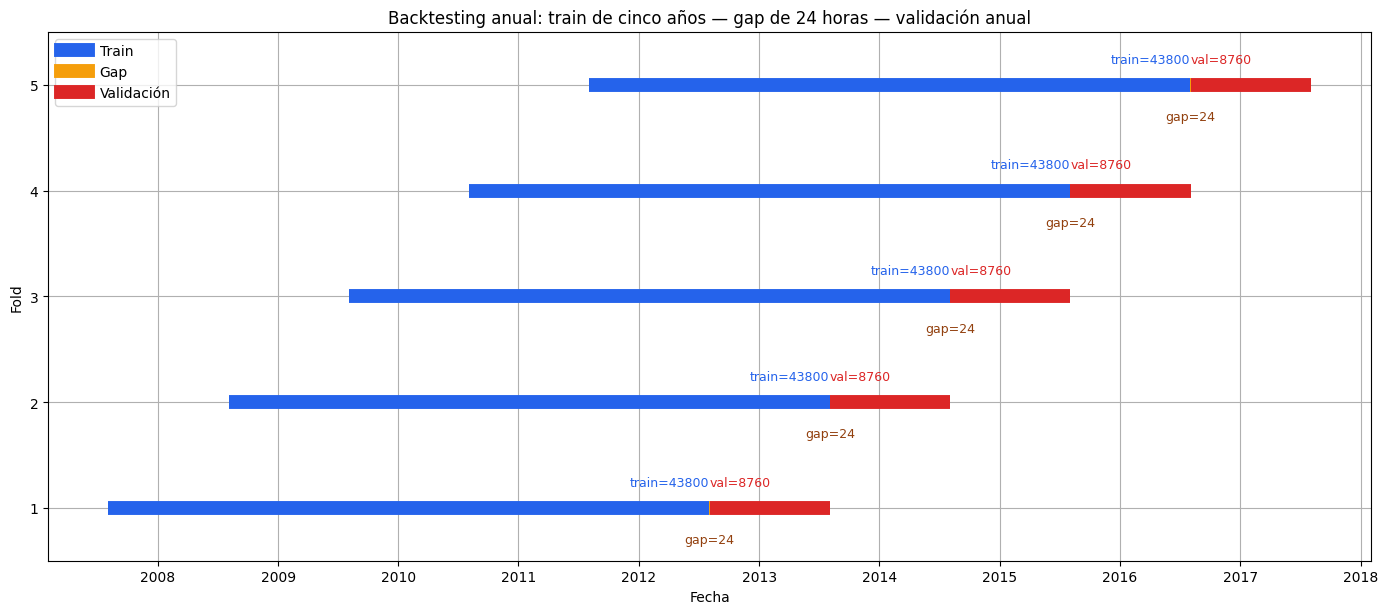

,fold,train_inicio,train_fin,n_train,gap_inicio,gap_fin,n_gap,val_inicio,val_fin,n_val
0,1,2007-08-04 09:00:00,2012-08-02 19:00:00,43800,2012-08-02 20:00:00,2012-08-03 19:00:00,24,2012-08-03 20:00:00,2013-08-03 21:00:00,8760
1,2,2008-08-03 11:00:00,2013-08-02 21:00:00,43800,2013-08-02 22:00:00,2013-08-03 21:00:00,24,2013-08-03 22:00:00,2014-08-03 23:00:00,8760
2,3,2009-08-03 13:00:00,2014-08-02 23:00:00,43800,2014-08-03 00:00:00,2014-08-03 23:00:00,24,2014-08-04 00:00:00,2015-08-03 23:00:00,8760
3,4,2010-08-03 15:00:00,2015-08-02 23:00:00,43800,2015-08-03 00:00:00,2015-08-03 23:00:00,24,2015-08-04 00:00:00,2016-08-02 23:00:00,8760
4,5,2011-08-03 18:00:00,2016-08-01 23:00:00,43800,2016-08-02 00:00:00,2016-08-02 23:00:00,24,2016-08-03 00:00:00,2017-08-02 23:00:00,8760


Frontera temporal del último fold:


,elemento,fecha
0,Fin del train,2016-08-01 23:00:00
1,Última hora del gap,2016-08-02 23:00:00
2,Inicio de validación,2016-08-03 00:00:00


lag_1 de la primera fila de validación: 35583.0
valor real de la última hora del gap: 35583.0
Coinciden: True
Resultados por fold — validación anual con gap:


,fold,inicio_train,fin_train,inicio_val,fin_val,n_train,MAE,RMSE
0,1,2007-08-04 09:00:00,2012-08-02 19:00:00,2012-08-03 20:00:00,2013-08-03 21:00:00,43800,1408.903599,1869.055048
1,2,2008-08-03 11:00:00,2013-08-02 21:00:00,2013-08-03 22:00:00,2014-08-03 23:00:00,43800,1398.535778,1783.480110
2,3,2009-08-03 13:00:00,2014-08-02 23:00:00,2014-08-04 00:00:00,2015-08-03 23:00:00,43800,1375.794092,1730.816418
3,4,2010-08-03 15:00:00,2015-08-02 23:00:00,2015-08-04 00:00:00,2016-08-02 23:00:00,43800,1382.012941,1764.151766
4,5,2011-08-03 18:00:00,2016-08-01 23:00:00,2016-08-03 00:00:00,2017-08-02 23:00:00,43800,1403.131108,1863.322260


RMSE medio con gap: 1802.1651201756697


In [ ]:
split_gap = TimeSeriesSplit(
    n_splits=5,
    test_size=HORAS_ANIO,
    max_train_size=HORAS_ANIO * VENTANA_TRAIN_ANIOS,
    gap=24
)

print("Interpretación:")
print("- Azul = train de hasta cinco años.")
print("- Naranja = 24 horas excluidas del train.")
print("- Rojo = un año completo de validación.")
print()

resumen_gap = graficar_ventanas(
    split_gap,
    X_dev,
    titulo="Backtesting anual: train de cinco años — gap de 24 horas — validación anual"
)

display(resumen_gap)

# Mostrar qué ocurre en el primer registro de validación del último fold
for fold, (tr, va) in enumerate(split_gap.split(X_dev), start=1):
    if fold == 5:
        ultimo_fold_tr, ultimo_fold_va = tr, va
        break

fecha_fin_train = X_dev.index[ultimo_fold_tr[-1]]
fecha_inicio_val = X_dev.index[ultimo_fold_va[0]]
fecha_ultimo_gap = X_dev.index[ultimo_fold_va[0]-1]

chequeo_gap = pd.DataFrame({
    "elemento": ["Fin del train", "Última hora del gap", "Inicio de validación"],
    "fecha": [fecha_fin_train, fecha_ultimo_gap, fecha_inicio_val]
})
print("Frontera temporal del último fold:")
display(chequeo_gap)

primer_lag_val = X_dev.iloc[ultimo_fold_va[0]]["lag_1"]
valor_real_gap = y_dev.iloc[ultimo_fold_va[0]-1]
print("lag_1 de la primera fila de validación:", primer_lag_val)
print("valor real de la última hora del gap:", valor_real_gap)
print("Coinciden:", np.isclose(primer_lag_val, valor_real_gap))

res_gap,pred_gap=backtesting_tabular(modelo_base,X_dev,y_dev,split_gap)
print("Resultados por fold — validación anual con gap:")
display(res_gap)
print("RMSE medio con gap:",res_gap.RMSE.mean())

La tabla y el chequeo muestran una distinción esencial:

- El `gap` evita que esas 24 horas entrenen el modelo.
- Pero una matriz `X_val` preconstruida puede seguir usándolas como **contexto real** para crear `lag_1`.

Esto no es un error si el gap ya estaba disponible al pronosticar la validación. Si esas 24 horas no estaban disponibles, entonces la evaluación tabular es optimista y deberíamos generar primero 24 predicciones recursivas para atravesar el hueco.

**Esto se puede medir, no solo enunciar.** Más abajo, después de construir el forecast recursivo, vamos a tomar este mismo gap de 24 horas y comparar, con el mismo modelo, qué tan distinto (y qué tan peor) es el resultado si lo atravesamos "a ciegas" en vez de asumirlo conocido.

## 7. Nivel 5 — Validación tabular anual vs demostración recursiva de 48 horas

Hasta aquí mantuvimos la condición original de **cinco validaciones anuales**. Esa evaluación tabular responde:

> ¿Cómo funciona el modelo durante años completos si las features de cada hora están disponibles cuando corresponde?

Ahora hacemos una demostración distinta, con horizonte de 48 horas, para responder:

> Si hoy emitimos de una sola vez un forecast para las próximas 48 horas, ¿qué ocurre cuando todavía no conocemos los valores reales intermedios?

No reemplazamos el backtesting anual. Agregamos una segunda prueba que representa otro uso operativo.

En la **validación tabular anual**, `X_val` ya viene construido fila por fila. En la hora 2 de la validación, `lag_1` utiliza el valor real de la hora 1. Esto es correcto si el proceso se actualiza cada hora y recibe el dato real anterior.

En un **forecast de 48 horas emitido una sola vez**, la hora 1 todavía no ocurrió. Por eso, para construir la fila de la hora 2, debemos utilizar la predicción de la hora 1 como `lag_1`.

La tabla y el dibujo siguientes muestran exactamente dónde se separan ambas estrategias.

In [ ]:
def construir_fila_recursiva(historial, fecha):
    return pd.DataFrame([{
        "hour":fecha.hour,
        "dayofweek":fecha.dayofweek,
        "month":fecha.month,
        "quarter":fecha.quarter,
        "dayofyear":fecha.dayofyear,
        "lag_1":historial[-1],
        "lag_24":historial[-24],
        "lag_168":historial[-168],
        "media_24":np.mean(historial[-24:])
    }],index=[fecha])[FEATURES]


def forecast_recursivo(modelo,historial,fechas,guardar_traza=False):
    hist=list(historial)
    out=[]
    trazas=[]
    for h, fecha in enumerate(fechas, start=1):
        fila=construir_fila_recursiva(hist,fecha)
        pred=float(modelo.predict(fila)[0])
        out.append(pred)
        if guardar_traza:
            trazas.append({
                "horizonte": h,
                "fecha": fecha,
                "hour": int(fila.iloc[0]["hour"]),
                "dayofweek": int(fila.iloc[0]["dayofweek"]),
                "lag_1": float(fila.iloc[0]["lag_1"]),
                "lag_24": float(fila.iloc[0]["lag_24"]),
                "media_24": float(fila.iloc[0]["media_24"]),
                "pred": pred
            })
        hist.append(pred)
    if guardar_traza:
        return np.array(out), pd.DataFrame(trazas)
    return np.array(out)


def backtesting_recursivo(modelo_base,df,splitter,horizonte=48):
    filas=[]; predicciones=[]
    X=df[FEATURES]; y=df[TARGET]
    for fold,(tr,va) in enumerate(splitter.split(X),1):
        va=va[:horizonte]
        modelo=clone(modelo_base)
        modelo.fit(X.iloc[tr],y.iloc[tr])
        fechas=y.index[va]
        y_hat=forecast_recursivo(modelo,y.iloc[tr].values,fechas)
        y_real=y.iloc[va]
        filas.append({"fold":fold,
                      "MAE":mean_absolute_error(y_real,y_hat),
                      "RMSE":mean_squared_error(y_real,y_hat)**0.5})
        predicciones.append(pd.DataFrame({"real":y_real.values,"pred":y_hat,
                                          "horizonte":np.arange(1,len(va)+1),"fold":fold},index=fechas))
    return pd.DataFrame(filas),pd.concat(predicciones)

split_48=TimeSeriesSplit(n_splits=4,test_size=48,gap=0)
res_rec,pred_rec=backtesting_recursivo(modelo_base,train,split_48,horizonte=48)
print("Resultados por fold (forecast recursivo de 48 horas):")
display(res_rec)
print("RMSE recursivo medio:",res_rec.RMSE.mean())


Resultados por fold (forecast recursivo de 48 horas):


,fold,MAE,RMSE
0,1,3852.519084,4363.981175
1,2,3832.674520,4167.185468
2,3,5795.094279,6946.554724
3,4,5028.512939,6286.011560


RMSE recursivo medio: 5440.933231952976


Primeras filas de la ventana de validación (comparación tabular vs recursiva):


,fecha,horizonte,lag_1_tab,lag_24_tab,media_24_tab,real,lag_1_rec,lag_24_rec,media_24_rec,pred_rec
0,2017-08-01 00:00:00,1,36841.0,28047.0,34613.083333,33342.0,36841.000000,28047.0,34613.083333,34558.144531
1,2017-08-01 01:00:00,2,33342.0,25836.0,34833.708333,30396.0,34558.144531,25836.0,34884.381022,32603.888672
2,2017-08-01 02:00:00,3,30396.0,24456.0,35023.708333,28443.0,32603.888672,24456.0,35166.376383,30708.207031
3,2017-08-01 03:00:00,4,28443.0,23519.0,35189.833333,27128.0,30708.207031,23519.0,35426.885010,29119.994141
4,2017-08-01 04:00:00,5,27128.0,23152.0,35340.208333,26409.0,29119.994141,23152.0,35660.259766,28141.503906
5,2017-08-01 05:00:00,6,26409.0,23445.0,35475.916667,26422.0,28141.503906,23445.0,35868.155762,27600.072266


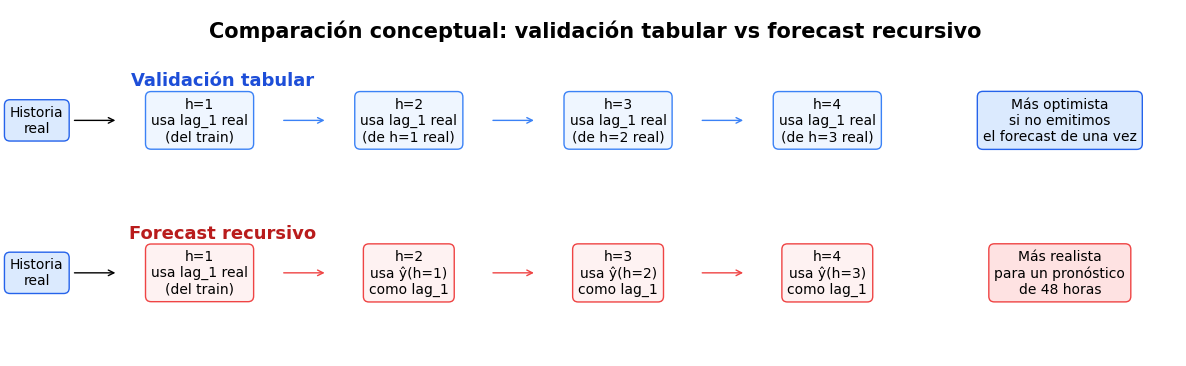

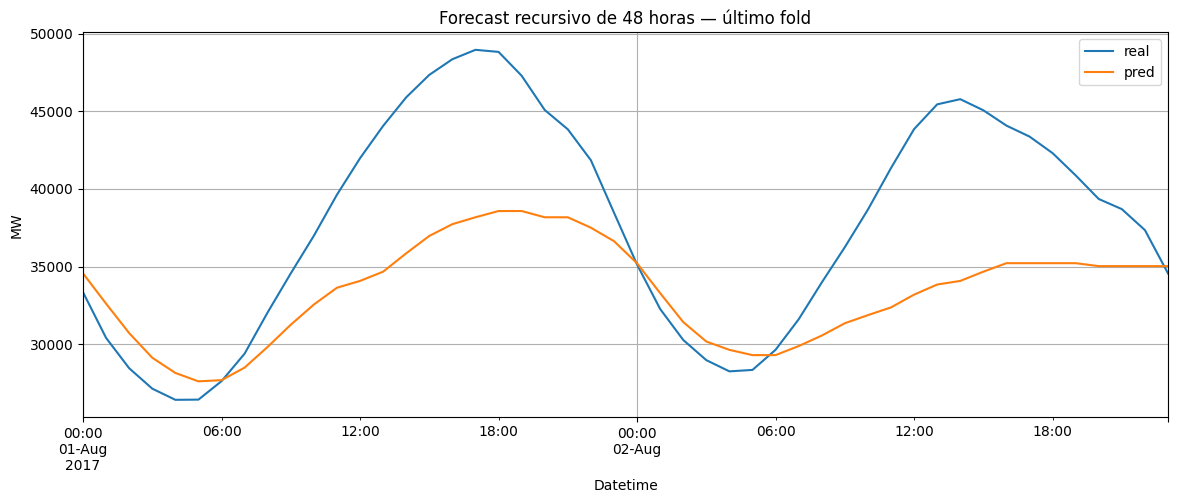

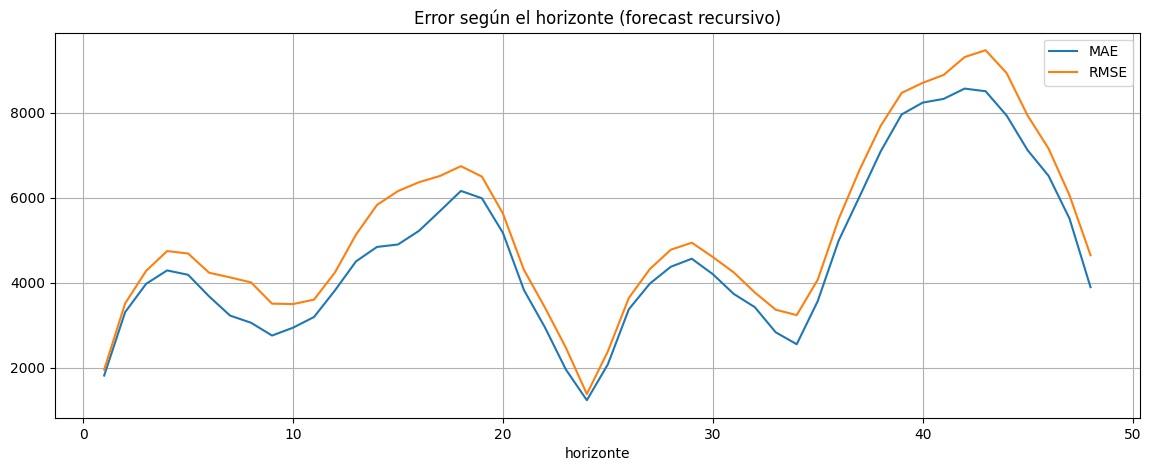

In [ ]:
# -----------------------------
# Comparación visual y tabular: tabular vs recursivo
# -----------------------------
fold_demo = 4
for i, (tr, va) in enumerate(split_48.split(train[FEATURES]), start=1):
    if i == fold_demo:
        tr_demo, va_demo = tr, va
        break

X_tr_demo = train.iloc[tr_demo][FEATURES]
y_tr_demo = train.iloc[tr_demo][TARGET]
X_va_demo = train.iloc[va_demo][FEATURES]
y_va_demo = train.iloc[va_demo][TARGET]

modelo_demo = clone(modelo_base)
modelo_demo.fit(X_tr_demo, y_tr_demo)

# Tabla tabular: cómo vienen construidas las primeras filas de validación
n_demo = 6
tabla_tabular = X_va_demo[["lag_1", "lag_24", "media_24"]].head(n_demo).copy()
tabla_tabular["real"] = y_va_demo.head(n_demo).values
tabla_tabular["horizonte"] = np.arange(1, n_demo + 1)
tabla_tabular.index.name = "fecha"

# Trazas recursivas para las mismas fechas
_, traza_rec = forecast_recursivo(modelo_demo, y_tr_demo.values, y_va_demo.index[:n_demo], guardar_traza=True)
traza_rec = traza_rec[["horizonte", "fecha", "lag_1", "lag_24", "media_24", "pred"]].copy()

comparacion = (
    tabla_tabular.reset_index()[["fecha", "horizonte", "lag_1", "lag_24", "media_24", "real"]]
    .merge(
        traza_rec.rename(columns={
            "lag_1": "lag_1_rec",
            "lag_24": "lag_24_rec",
            "media_24": "media_24_rec",
            "pred": "pred_rec"
        }),
        on=["fecha", "horizonte"],
        how="left"
    )
    .rename(columns={
        "lag_1": "lag_1_tab",
        "lag_24": "lag_24_tab",
        "media_24": "media_24_tab"
    })
)

print("Primeras filas de la ventana de validación (comparación tabular vs recursiva):")
display(comparacion)

# Dibujo conceptual
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.axis("off")

# Títulos
ax.text(0.5, 0.92, "Comparación conceptual: validación tabular vs forecast recursivo", ha="center", fontsize=15, weight="bold")
ax.text(0.18, 0.78, "Validación tabular", ha="center", fontsize=13, color="#1d4ed8", weight="bold")
ax.text(0.18, 0.34, "Forecast recursivo", ha="center", fontsize=13, color="#b91c1c", weight="bold")

# Historia observada
for y0 in [0.68, 0.24]:
    ax.text(0.02, y0, "Historia\nreal", ha="center", va="center", bbox=dict(boxstyle="round,pad=0.4", fc="#dbeafe", ec="#2563eb"))
    ax.annotate("", xy=(0.09, y0), xytext=(0.05, y0), arrowprops=dict(arrowstyle="->"))

# Cajas tabular
xs = [0.16, 0.34, 0.52, 0.70]
labels_tab = [
    "h=1\nusa lag_1 real\n(del train)",
    "h=2\nusa lag_1 real\n(de h=1 real)",
    "h=3\nusa lag_1 real\n(de h=2 real)",
    "h=4\nusa lag_1 real\n(de h=3 real)"
]
for x, lab in zip(xs, labels_tab):
    ax.text(x, 0.68, lab, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", fc="#eff6ff", ec="#3b82f6"))
for x1, x2 in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(x2-0.07, 0.68), xytext=(x1+0.07, 0.68), arrowprops=dict(arrowstyle="->", color="#3b82f6"))

# Cajas recursivo
labels_rec = [
    "h=1\nusa lag_1 real\n(del train)",
    "h=2\nusa ŷ(h=1)\ncomo lag_1",
    "h=3\nusa ŷ(h=2)\ncomo lag_1",
    "h=4\nusa ŷ(h=3)\ncomo lag_1"
]
for x, lab in zip(xs, labels_rec):
    ax.text(x, 0.24, lab, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", fc="#fef2f2", ec="#ef4444"))
for x1, x2 in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(x2-0.07, 0.24), xytext=(x1+0.07, 0.24), arrowprops=dict(arrowstyle="->", color="#ef4444"))

ax.text(0.90, 0.68, "Más optimista\nsi no emitimos\nel forecast de una vez", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="#dbeafe", ec="#2563eb"))
ax.text(0.90, 0.24, "Más realista\npara un pronóstico\nde 48 horas", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="#fee2e2", ec="#ef4444"))
plt.show()

# Ejemplo gráfico sobre el último fold recursivo
plot_df=pred_rec[pred_rec.fold==pred_rec.fold.max()]
plot_df[["real","pred"]].plot(title="Forecast recursivo de 48 horas — último fold")
plt.ylabel("MW")
plt.show()

metricas_h=(pred_rec.groupby("horizonte")
            .apply(lambda g: pd.Series({"MAE":mean_absolute_error(g.real,g.pred),
                                        "RMSE":mean_squared_error(g.real,g.pred)**0.5})))
metricas_h.plot(title="Error según el horizonte (forecast recursivo)")
plt.show()


### 7.1 Aplicado al gap real de 24 horas: ¿cuánto optimismo esconde la validación tabular?

En la sección anterior (Nivel 4) vimos que el `lag_1` de la primera fila de validación coincide
con el valor real de la última hora del gap. Eso es correcto **si estamos haciendo backtesting**:
como ya pasó el tiempo, esas 24 horas están sentadas en el dataset con su valor real, aunque el
modelo no haya entrenado con ellas.

Pero si estuviéramos parados en producción real, un poco antes de esas 24 horas, no tendríamos ese
valor real todavía. Tendríamos que generarlo prediciendo, hora a hora, con el propio modelo — igual
que en el forecast recursivo de más arriba.

A continuación tomamos **el mismo modelo, entrenado con exactamente el mismo train**, y le hacemos
construir las primeras horas de validación de dos maneras distintas:

- **Camino A — "gap conocido"**: usa el valor real de cada hora del gap para construir `lag_1`,
  `lag_24` y `media_24`, porque esas columnas ya fueron calculadas sobre toda la serie antes de
  hacer el split. Esto es exactamente lo que hace la validación tabular tal cual está armada en
  este notebook.
- **Camino B — "gap desconocido" (recursivo)**: ignora a propósito los valores reales del gap y
  los reemplaza por predicciones propias, generadas recursivamente, tal como pasaría si esas 24
  horas todavía no hubieran sucedido.

El modelo es idéntico en los dos caminos. Lo único que cambia es **qué información usamos para
construir el contexto** de las primeras horas de test.

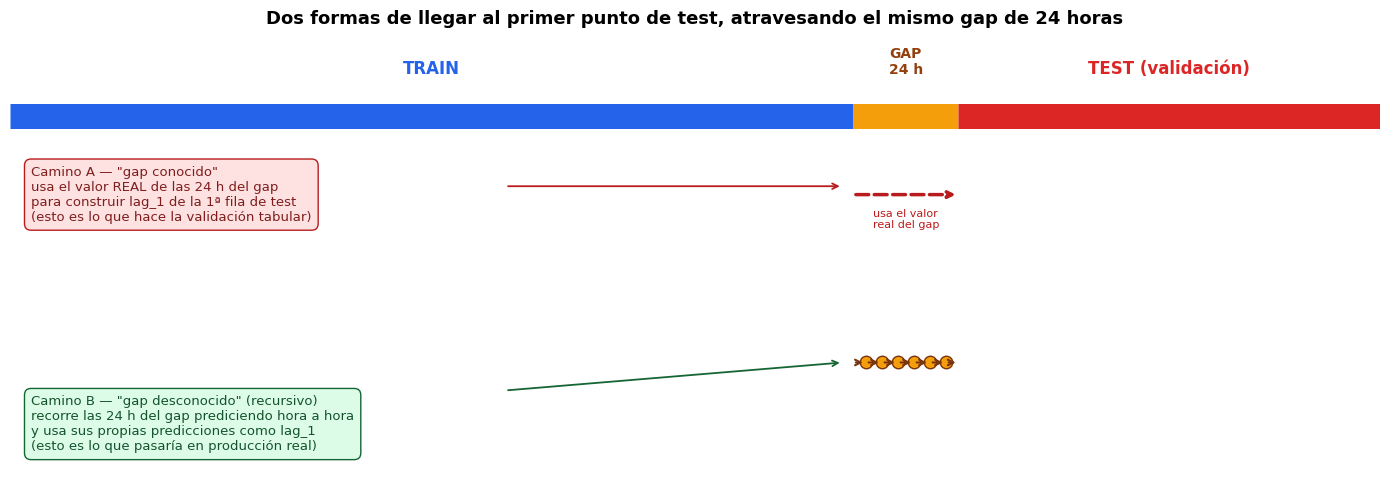

In [ ]:
# -----------------------------
# Diagrama esquemático: dos caminos posibles para atravesar el mismo gap de 24 horas
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 1.6)
ax.axis("off")

# Barra de tiempo: TRAIN | GAP | TEST
ax.plot([0, 8], [1.3, 1.3], color=ROLE_COLORS["train"], lw=18, solid_capstyle="butt")
ax.plot([8, 9], [1.3, 1.3], color=ROLE_COLORS["gap"], lw=18, solid_capstyle="butt")
ax.plot([9, 13], [1.3, 1.3], color=ROLE_COLORS["val"], lw=18, solid_capstyle="butt")
ax.text(4, 1.45, "TRAIN", ha="center", fontsize=12, weight="bold", color=ROLE_COLORS["train"])
ax.text(8.5, 1.45, "GAP\n24 h", ha="center", fontsize=10, weight="bold", color="#92400e")
ax.text(11, 1.45, "TEST (validación)", ha="center", fontsize=12, weight="bold", color=ROLE_COLORS["val"])

# Camino A: "salto" directo usando el valor real del gap
ax.annotate("", xy=(9, 1.02), xytext=(8, 1.02),
            arrowprops=dict(arrowstyle="-|>", color="#b91c1c", lw=2.5, linestyle="--"))
ax.text(8.5, 0.90, "usa el valor\nreal del gap", ha="center", fontsize=8, color="#b91c1c")
ax.text(0.2, 1.02,
        "Camino A — \"gap conocido\"\nusa el valor REAL de las 24 h del gap\npara construir lag_1 de la 1ª fila de test\n(esto es lo que hace la validación tabular)",
        ha="left", va="center", fontsize=9.5, color="#7f1d1d",
        bbox=dict(boxstyle="round,pad=0.5", fc="#fee2e2", ec="#b91c1c"))
ax.annotate("", xy=(7.9, 1.05), xytext=(4.7, 1.05), arrowprops=dict(arrowstyle="->", color="#b91c1c", lw=1.3))

# Camino B: recorrido recursivo hora a hora dentro del gap
xs_gap = np.linspace(8.12, 8.88, 6)
for i, x in enumerate(xs_gap):
    ax.plot(x, 0.42, "o", color=ROLE_COLORS["gap"], markersize=9, mec="#78350f")
    prev = xs_gap[i - 1] if i > 0 else 8
    ax.annotate("", xy=(x, 0.42), xytext=(prev, 0.42),
                arrowprops=dict(arrowstyle="->", color="#78350f", lw=1.5))
ax.annotate("", xy=(9, 0.42), xytext=(xs_gap[-1], 0.42), arrowprops=dict(arrowstyle="->", color="#78350f", lw=1.5))
ax.text(0.2, 0.20,
        "Camino B — \"gap desconocido\" (recursivo)\nrecorre las 24 h del gap prediciendo hora a hora\ny usa sus propias predicciones como lag_1\n(esto es lo que pasaría en producción real)",
        ha="left", va="center", fontsize=9.5, color="#14532d",
        bbox=dict(boxstyle="round,pad=0.5", fc="#dcfce7", ec="#166534"))
ax.annotate("", xy=(7.9, 0.42), xytext=(4.7, 0.32), arrowprops=dict(arrowstyle="->", color="#166534", lw=1.3))

ax.set_title("Dos formas de llegar al primer punto de test, atravesando el mismo gap de 24 horas",
             fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# Camino A vs Camino B: mismo modelo, mismo train, distinta forma de atravesar el gap
# -----------------------------
FOLD_RIESGO = 5
VENTANA_RIESGO = 48  # horas de test a comparar, justo después del gap

splits_gap = list(split_gap.split(X_dev))
tr_r, va_r = splits_gap[FOLD_RIESGO - 1]
va_r = va_r[:VENTANA_RIESGO]

gap_start = tr_r[-1] + 1
gap_end = va_r[0] - 1
fechas_gap = X_dev.index[gap_start:gap_end + 1]
fechas_test_ventana = X_dev.index[va_r]

print(f"Fold usado: {FOLD_RIESGO}")
print("Fin de train:            ", X_dev.index[tr_r[-1]])
print("Gap:                     ", fechas_gap[0], "→", fechas_gap[-1], f"({len(fechas_gap)} horas)")
print("Ventana de test analizada:", fechas_test_ventana[0], "→", fechas_test_ventana[-1])

# Un único modelo, entrenado una única vez con el mismo train:
# así la única diferencia entre A y B es cómo se atraviesa el gap, no el modelo.
modelo_riesgo = clone(modelo_base)
modelo_riesgo.fit(X_dev.iloc[tr_r], y_dev.iloc[tr_r])

# --- Camino A: "gap conocido" -> usa las columnas ya precalculadas con el valor REAL del gap ---
X_test_ventana = X_dev.iloc[va_r]
pred_A = modelo_riesgo.predict(X_test_ventana)

# --- Camino B: "gap desconocido" -> arranca solo con historial hasta el fin del train, y
#     atraviesa el gap + la ventana de test de forma recursiva, sin mirar ni un valor real del gap ---
historial_B = list(y_dev.iloc[tr_r].values)
fechas_recorrido = X_dev.index[gap_start: va_r[-1] + 1]
pred_recorrido_B, traza_B = forecast_recursivo(modelo_riesgo, historial_B, fechas_recorrido, guardar_traza=True)

n_gap = len(fechas_gap)
pred_B = pred_recorrido_B[n_gap:]
traza_B_test = traza_B.iloc[n_gap:].reset_index(drop=True)

y_real_ventana = y_dev.iloc[va_r]

mae_A = mean_absolute_error(y_real_ventana, pred_A)
mae_B = mean_absolute_error(y_real_ventana, pred_B)
rmse_A = mean_squared_error(y_real_ventana, pred_A) ** 0.5
rmse_B = mean_squared_error(y_real_ventana, pred_B) ** 0.5

print()
print(f"Camino A (gap conocido)                -> MAE={mae_A:,.1f}   RMSE={rmse_A:,.1f}")
print(f"Camino B (gap desconocido, recursivo)   -> MAE={mae_B:,.1f}   RMSE={rmse_B:,.1f}")
print(f"Diferencia relativa en MAE: {100 * (mae_B - mae_A) / mae_A:+.1f}%")

Fold usado: 5
Fin de train:             2016-08-01 23:00:00
Gap:                      2016-08-02 00:00:00 → 2016-08-02 23:00:00 (24 horas)
Ventana de test analizada: 2016-08-03 00:00:00 → 2016-08-04 23:00:00

Camino A (gap conocido)                -> MAE=1,608.4   RMSE=1,836.4
Camino B (gap desconocido, recursivo)   -> MAE=5,238.9   RMSE=5,878.4
Diferencia relativa en MAE: +225.7%


In [ ]:
# Tabla: cómo se construyó lag_1 en cada camino, hora a hora, para las primeras filas de test
n_tabla = 8
tabla_riesgo = pd.DataFrame({
    "fecha": fechas_test_ventana[:n_tabla],
    "valor_real_y": y_real_ventana.values[:n_tabla],
    "lag_1_caminoA (real del gap/test)": X_test_ventana["lag_1"].values[:n_tabla],
    "lag_1_caminoB (predicho, recursivo)": traza_B_test["lag_1"].values[:n_tabla],
    "pred_caminoA": pred_A[:n_tabla],
    "pred_caminoB": pred_B[:n_tabla],
})
tabla_riesgo["dif_pred (B - A)"] = tabla_riesgo["pred_caminoB"] - tabla_riesgo["pred_caminoA"]
print("Primeras horas de la ventana de test: cómo se construyó lag_1 en cada camino")
display(tabla_riesgo.round(1))

Primeras horas de la ventana de test: cómo se construyó lag_1 en cada camino


,fecha,valor_real_y,lag_1_caminoA (real del gap/test),"lag_1_caminoB (predicho, recursivo)",pred_caminoA,pred_caminoB,dif_pred (B - A)
0,2016-08-03 00:00:00,32181.0,35583.0,36800.9,34760.898438,36413.3,1652.4
1,2016-08-03 01:00:00,29462.0,32181.0,36413.3,31743.900391,35690.0,3946.2
2,2016-08-03 02:00:00,27717.0,29462.0,35690.0,30151.900391,34760.9,4609.0
3,2016-08-03 03:00:00,26540.0,27717.0,34760.9,28919.199219,33713.3,4794.1
4,2016-08-03 04:00:00,25912.0,26540.0,33713.3,28348.500000,32966.1,4617.6
5,2016-08-03 05:00:00,26030.0,25912.0,32966.1,28109.500000,32192.2,4082.8
6,2016-08-03 06:00:00,27298.0,26030.0,32192.2,28676.300781,32167.4,3491.1
7,2016-08-03 07:00:00,29102.0,27298.0,32167.4,29183.900391,32361.3,3177.4


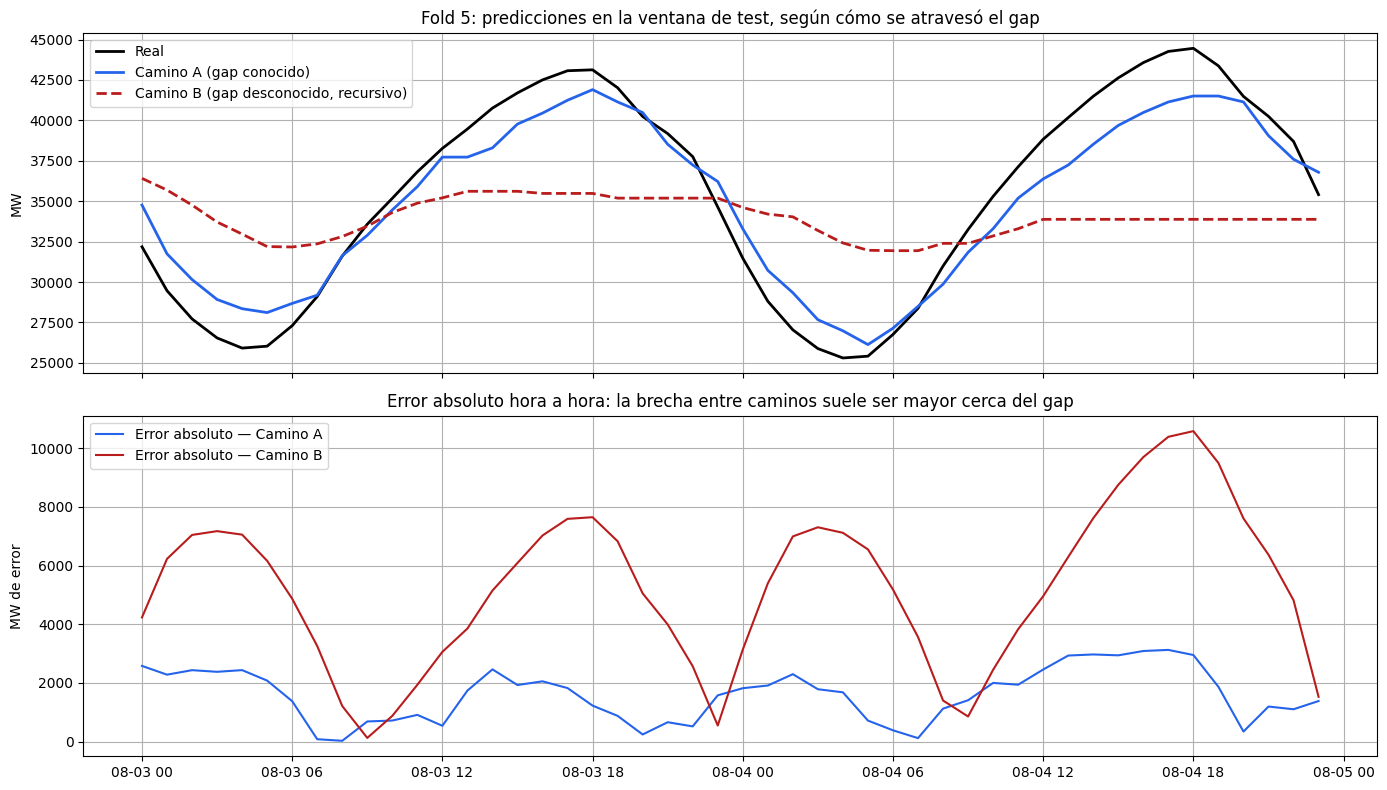

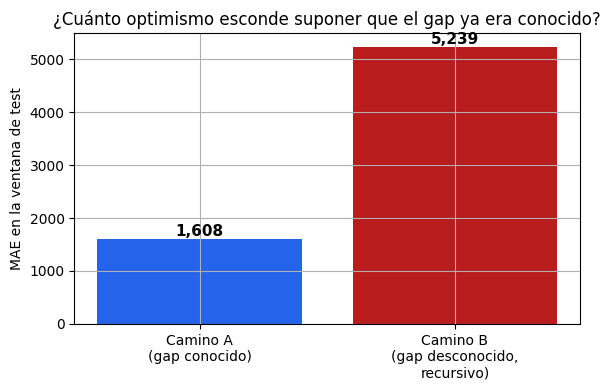

In [ ]:
# -----------------------------
# Visualización: real vs Camino A vs Camino B, a lo largo de la ventana de test
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(fechas_test_ventana, y_real_ventana.values, label="Real", color="black", lw=2)
axes[0].plot(fechas_test_ventana, pred_A, label="Camino A (gap conocido)", color="#2563eb", lw=2)
axes[0].plot(fechas_test_ventana, pred_B, label="Camino B (gap desconocido, recursivo)",
             color="#b91c1c", lw=2, linestyle="--")
axes[0].set_title(f"Fold {FOLD_RIESGO}: predicciones en la ventana de test, según cómo se atravesó el gap")
axes[0].set_ylabel("MW")
axes[0].legend()

error_A = np.abs(y_real_ventana.values - pred_A)
error_B = np.abs(y_real_ventana.values - pred_B)
axes[1].plot(fechas_test_ventana, error_A, label="Error absoluto — Camino A", color="#2563eb")
axes[1].plot(fechas_test_ventana, error_B, label="Error absoluto — Camino B", color="#b91c1c")
axes[1].set_title("Error absoluto hora a hora: la brecha entre caminos suele ser mayor cerca del gap")
axes[1].set_ylabel("MW de error")
axes[1].legend()
plt.tight_layout()
plt.show()

# Barras: comparación de MAE
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Camino A\n(gap conocido)", "Camino B\n(gap desconocido,\nrecursivo)"],
                 [mae_A, mae_B], color=["#2563eb", "#b91c1c"])
ax.set_ylabel("MAE en la ventana de test")
ax.set_title("¿Cuánto optimismo esconde suponer que el gap ya era conocido?")
for barra, v in zip(barras, [mae_A, mae_B]):
    ax.text(barra.get_x() + barra.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom",
            fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

**Lectura de esta comparación:**

- El modelo es exactamente el mismo en los dos caminos — mismo train, mismo `fit()`. Lo único que
  cambia es **qué información usamos para construir el contexto (lags, media móvil) de las
  primeras horas de test**.
- **Camino A** es lo que hace `TimeSeriesSplit(gap=24)` tal cual está armado en este notebook:
  como estamos haciendo *backtesting*, el valor real de esas 24 horas del gap ya está en el
  DataFrame, aunque el modelo no haya entrenado con él. Es el **Caso 1**: el gap ya es conocido al
  momento de evaluar.
- **Camino B** es lo que pasaría si esas 24 horas todavía no hubieran ocurrido — como en producción
  real. Ahí no queda otra que recorrer el gap **recursivamente**, con las propias predicciones del
  modelo. Es el **Caso 2**.
- La diferencia entre `mae_A` y `mae_B` es, ni más ni menos, **el riesgo que se corre si se
  confunde un backtesting (Caso 1) con la situación real de producción (Caso 2)**: el backtesting
  tabular, tal cual, reporta un error más optimista que el que realmente vas a tener el día que
  tengas que cruzar ese gap sin datos reales todavía.

> Regla práctica para el pipeline de producción: si tu proceso real tiene un gap de N horas/días
> entre el último dato disponible y el momento en que el forecast se usa, **nunca calcules los
> lags de esas N horas con datos reales que todavía no vas a tener**. Generalos recursivamente,
> como en el Camino B.

## 8. Nivel 6 — Comparación con baseline

In [ ]:
def baseline_persistencia(historial,h):
    return np.repeat(historial[-1],h)

filas=[]
X=train[FEATURES]; y=train[TARGET]
for fold,(tr,va) in enumerate(split_48.split(X),1):
    va=va[:48]
    y_real=y.iloc[va]
    y_hat=baseline_persistencia(y.iloc[tr].values,len(va))
    filas.append({"fold":fold,
                  "MAE":mean_absolute_error(y_real,y_hat),
                  "RMSE":mean_squared_error(y_real,y_hat)**0.5})
res_base=pd.DataFrame(filas)

display(pd.DataFrame({
    "XGBoost_recursivo":res_rec[["MAE","RMSE"]].mean(),
    "Persistencia":res_base[["MAE","RMSE"]].mean()
}))

,XGBoost_recursivo,Persistencia
MAE,4627.200205,6002.302083
RMSE,5440.933232,6852.769385


## 9. Evaluación final reservada

TEST FINAL TABULAR
MAE: 1361.2142884213417
RMSE: 1735.9668962359726


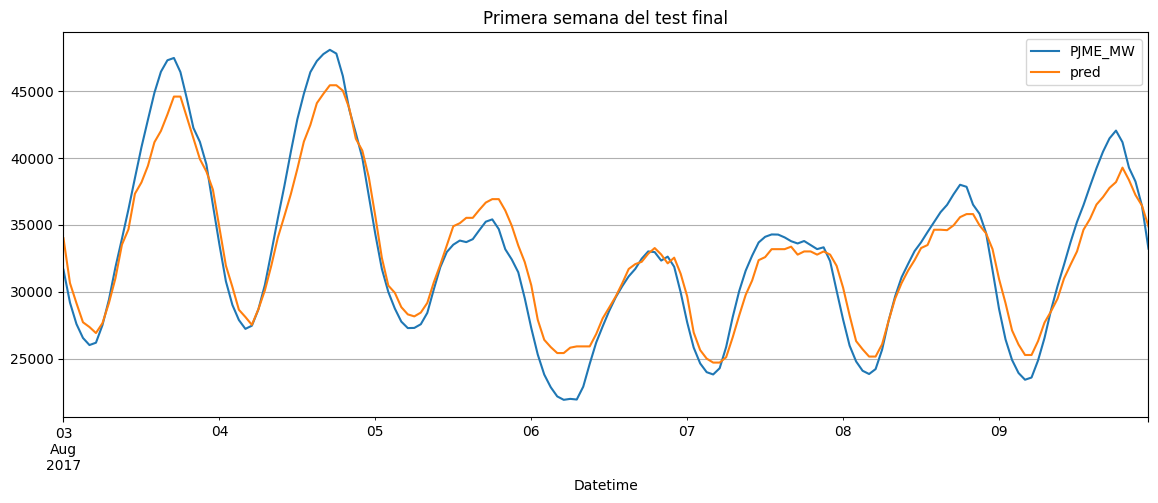

In [ ]:
modelo_final=clone(modelo_base)
modelo_final.fit(train[FEATURES],train[TARGET])

# Evaluación tabular sobre el test final: válida para actualización horaria con datos reales recientes.
y_hat_final=modelo_final.predict(test_final[FEATURES])
print("TEST FINAL TABULAR")
print("MAE:",mean_absolute_error(test_final[TARGET],y_hat_final))
print("RMSE:",mean_squared_error(test_final[TARGET],y_hat_final)**0.5)

muestra=test_final.iloc[:24*7].copy()
muestra["pred"]=y_hat_final[:len(muestra)]
muestra[[TARGET,"pred"]].plot(title="Primera semana del test final")
plt.show()

## 10. Lectura final del notebook

1. La condición original se conserva: **5 folds con 1 año de validación cada uno**.
2. La ventana expansiva agrega un año completo al train en cada fold.
3. La ventana deslizante mantiene el mismo horizonte anual, pero usa solo los últimos cinco años.
4. El gap separa train y validación, pero no pronostica el hueco automáticamente.
5. La validación tabular anual y el forecast recursivo de 48 horas responden preguntas operativas diferentes.
6. El test final de un año se mantiene reservado para una evaluación final sin sesgo de selección.
7. Con el mismo modelo y el mismo train, cuantificamos cuánto optimismo esconde asumir que el gap ya era conocido (Camino A) frente a atravesarlo recursivamente como en producción real (Camino B).

> No existe un único backtesting correcto para todo. La configuración debe reproducir la frecuencia de actualización, el horizonte y la disponibilidad real de información del sistema que queremos desplegar.